In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
from matplotlib.colors import to_rgb

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean


In [2]:
df_ameda = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_ameda_renamed.pkl')
df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/AMEDA/df_tilt_ameda.pkl')
df_ameda = df_ameda.merge(
    df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
    how='left',
    left_on=['Eddy', 'Day'],
    right_on=['Eddy', 'Day']
)
df_ameda


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,split2,merge,merge2,shapes2,interaction,interaction2,area,deta,TiltDis,TiltDir
0,1,1462,AE,159.538447,-33.372496,256,186,895.838095,919.548973,0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,46653.514371,-0.000011,NaN,NaN
1,1,1463,AE,159.686966,-33.160751,257,192,903.002279,946.853133,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4313.383226,-0.000164,NaN,NaN
2,1,1464,AE,159.649836,-33.118402,256,192,898.424872,950.150915,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,4336.799061,-0.000070,NaN,NaN
3,1,1465,AE,159.686966,-33.118402,257,193,901.765461,951.353349,0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,6480.379311,-0.000047,16.147158,80.585819
4,1,1466,AE,159.575577,-32.949006,254,196,886.770848,965.738198,0.000020,...,NaN,NaN,NaN,NaN,NaN,NaN,6101.676103,-0.000401,19.455358,63.680275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104565,3519,10643,CE,154.897235,-28.841152,125,252,327.112431,1244.142958,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,1147.953129,0.000186,8.196140,194.802223
104566,3519,10647,CE,154.860106,-29.052897,127,247,331.141370,1220.843200,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,8038.013328,0.000109,43.813072,358.254256
104567,3519,10648,CE,154.897235,-29.222293,130,244,340.502393,1204.416117,-0.000011,...,NaN,NaN,NaN,NaN,NaN,NaN,9866.414298,0.000095,NaN,NaN
104568,3519,10649,CE,154.377420,-28.417662,100,257,264.105244,1270.945276,-0.000010,...,NaN,NaN,NaN,NaN,NaN,NaN,5581.424065,0.000003,NaN,NaN


In [3]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


array([   2,   12,   22,   27,   30,   32,   33,   55,   82,   88,  104,
        110,  117,  120,  121,  146,  151,  161,  185,  198,  199,  202,
        203,  205,  222,  227,  228,  250,  257,  266,  272,  282,  295,
        314,  315,  316,  320,  328,  331,  333,  334,  341,  343,  345,
        353,  361,  364,  375,  380,  388,  402,  420,  425,  438,  449,
        466,  475,  485,  491,  493,  495,  497,  498,  500,  502,  508,
        520,  526,  530,  532,  544,  546,  549,  559,  578,  585,  589,
        591,  594,  595,  599,  601,  605,  613,  623,  627,  628,  631,
        646,  654,  655,  658,  659,  664,  665,  671,  673,  677,  687,
        700,  719,  720,  721,  723,  725,  730,  739,  746,  750,  751,
        753,  759,  761,  763,  768,  772,  782,  795,  799,  811,  814,
        823,  827,  832,  841,  846,  859,  870,  873,  876,  878,  879,
        882,  891,  896,  900,  906,  913,  919,  928,  931,  934,  945,
        949,  956,  962,  965,  979,  987,  995, 10

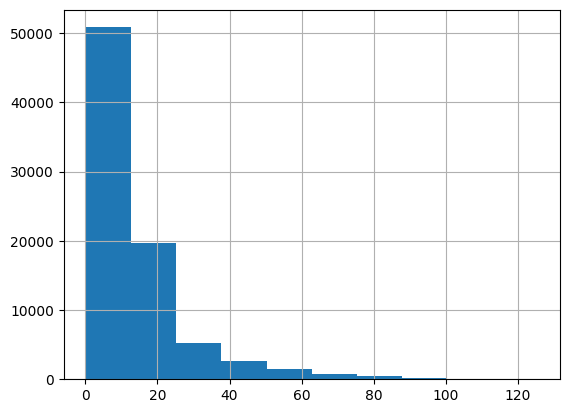

In [4]:
# df_ameda['h'] = h[df_ameda.ic, df_ameda.jc]
# dhdy, dhdx = np.gradient(h, X_grid[:,0], Y_grid[0,:])
# s = np.hypot(dhdx, dhdy)
# df_ameda['s'] = s[df_ameda.ic, df_ameda.jc]

# df_eddies_shelf = df_ameda[(df_ameda.h < 4e3) & (df_ameda.s > 20)]
# df_eddies_shelf.Eddy.unique()

df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=h,
    colname="h",
    circle_region_flag=True
)

dhdy, dhdx = np.gradient(h, X_grid[:,0], Y_grid[0,:])
s = np.hypot(dhdx, dhdy)
df_ameda = compute_core_mean( # mean value
    df_ameda,
    X_grid, Y_grid,
    mask_rho,
    fixed_field=s,
    colname="s",
    circle_region_flag=True
)
df_ameda['s'].hist()

df_eddies_shelf = df_ameda[(df_ameda.h < 4e3) & (df_ameda.s > 50)]
df_eddies_shelf.Eddy.unique()


(-45.73860301828215, 1595.0421870688813)

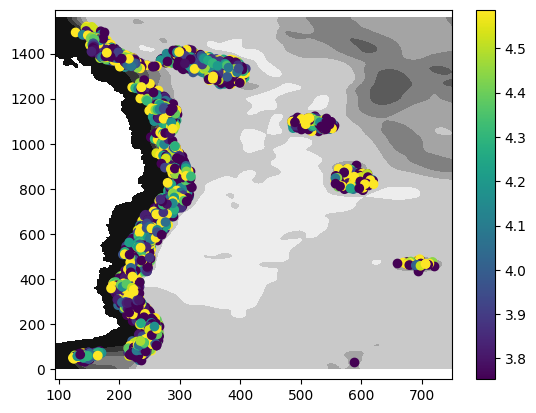

In [6]:
for eddy in df_eddies_shelf.Eddy.unique():
    df = df_eddies_shelf[df_eddies_shelf.Eddy==eddy]
    plt.scatter(df.xc, df.yc, c=df.TiltDis)
plt.colorbar()
xlim = plt.xlim()
ylim = plt.ylim()
plt.contourf(X_grid, Y_grid, np.where(mask_rho, h, np.nan), cmap='grey', zorder=0)
plt.xlim(xlim); plt.ylim(ylim)
# plt.axis('equal')


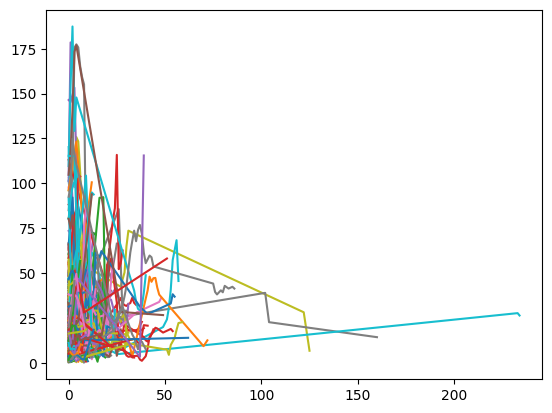

In [7]:
for eddy in df_eddies_shelf.Eddy.unique():
    df = df_eddies_shelf[df_eddies_shelf.Eddy==eddy]
    plt.plot(df.Day-df.Day.iloc[0], df.TiltDis)
    

In [8]:
def plot_single_eddy_tilt(
    eddy, df_eddies,
    X_grid, Y_grid, h, mask_rho,
    gap=5, s=5, figsize=(7, 7),
    tilt_dir_offset=-20,
    ax=None,
    cbar=False
):
    def point_b(a, r, theta_deg):
        theta_rad = np.radians(theta_deg)
        dx = r * np.sin(theta_rad)
        dy = r * np.cos(theta_rad)
        return a[0] - dx, a[1] - dy

    def darken(color, factor=0.7):
        r, g, b = to_rgb(color)
        return (r * factor, g * factor, b * factor)

    df_eddy = df_eddies.loc[df_eddies.Eddy.eq(eddy)].sort_values('Day').copy()

    if len(df_eddy) == 0:
        raise ValueError(f'Eddy {eddy} not found')

    cyc = df_eddy.Cyc.iloc[0]
    color = 'b' if cyc == 'CE' else 'r'

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    else:
        fig = ax.figure

    m = ax.contourf(
        X_grid, Y_grid,
        np.where(mask_rho, h / 1e3, np.nan),
        cmap='gray'
    )

    ax.plot(df_eddy.xc, df_eddy.yc, color=color, linewidth=0.5, zorder=1)

    for d, data in df_eddy.iterrows():

        x0, y0 = data.xc, data.yc
        tilt_dis = data.TiltDis
        tilt_dir = data.TiltDir

        if np.isnan(tilt_dis) or np.isnan(tilt_dir):
            ax.scatter(
                x0, y0,
                edgecolors=darken(color, 0.8),
                facecolors='none',
                s=15,
                zorder=3
            )
            continue

        xb, yb = point_b(
            [x0, y0],
            tilt_dis,
            (tilt_dir + tilt_dir_offset) % 360
        )

        ax.plot([x0, xb], [y0, yb], color=color, zorder=2)
        ax.scatter(x0, y0, color=darken(color, 0.8), s=s, zorder=3)

    ax.text(
        df_eddy.iloc[0].xc + 15,
        df_eddy.iloc[0].yc + 15,
        'A',
        color='r',
        fontsize=14
    )

    ax.set_title(f'{cyc}{eddy}')
    ax.set_xlabel('x (km)')
    ax.set_ylabel('y (km)')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(df_eddy.xc.min() - gap, df_eddy.xc.max() + gap)
    ax.set_ylim(df_eddy.yc.min() - gap, df_eddy.yc.max() + gap)

    if cbar:
        cb = fig.colorbar(m, ax=ax, location='top', shrink=0.7)
        cb.set_label('Bathymetry [km]')

    return fig, ax, m
    

In [16]:
valid_eddies = (
    df_eddies_shelf
    .groupby('Eddy')['TiltDis']
    .apply(lambda x: (x.isna().sum() == 6) and (x.notna().sum() >= 30))
)

eddies = valid_eddies[valid_eddies].index
len(eddies)


59

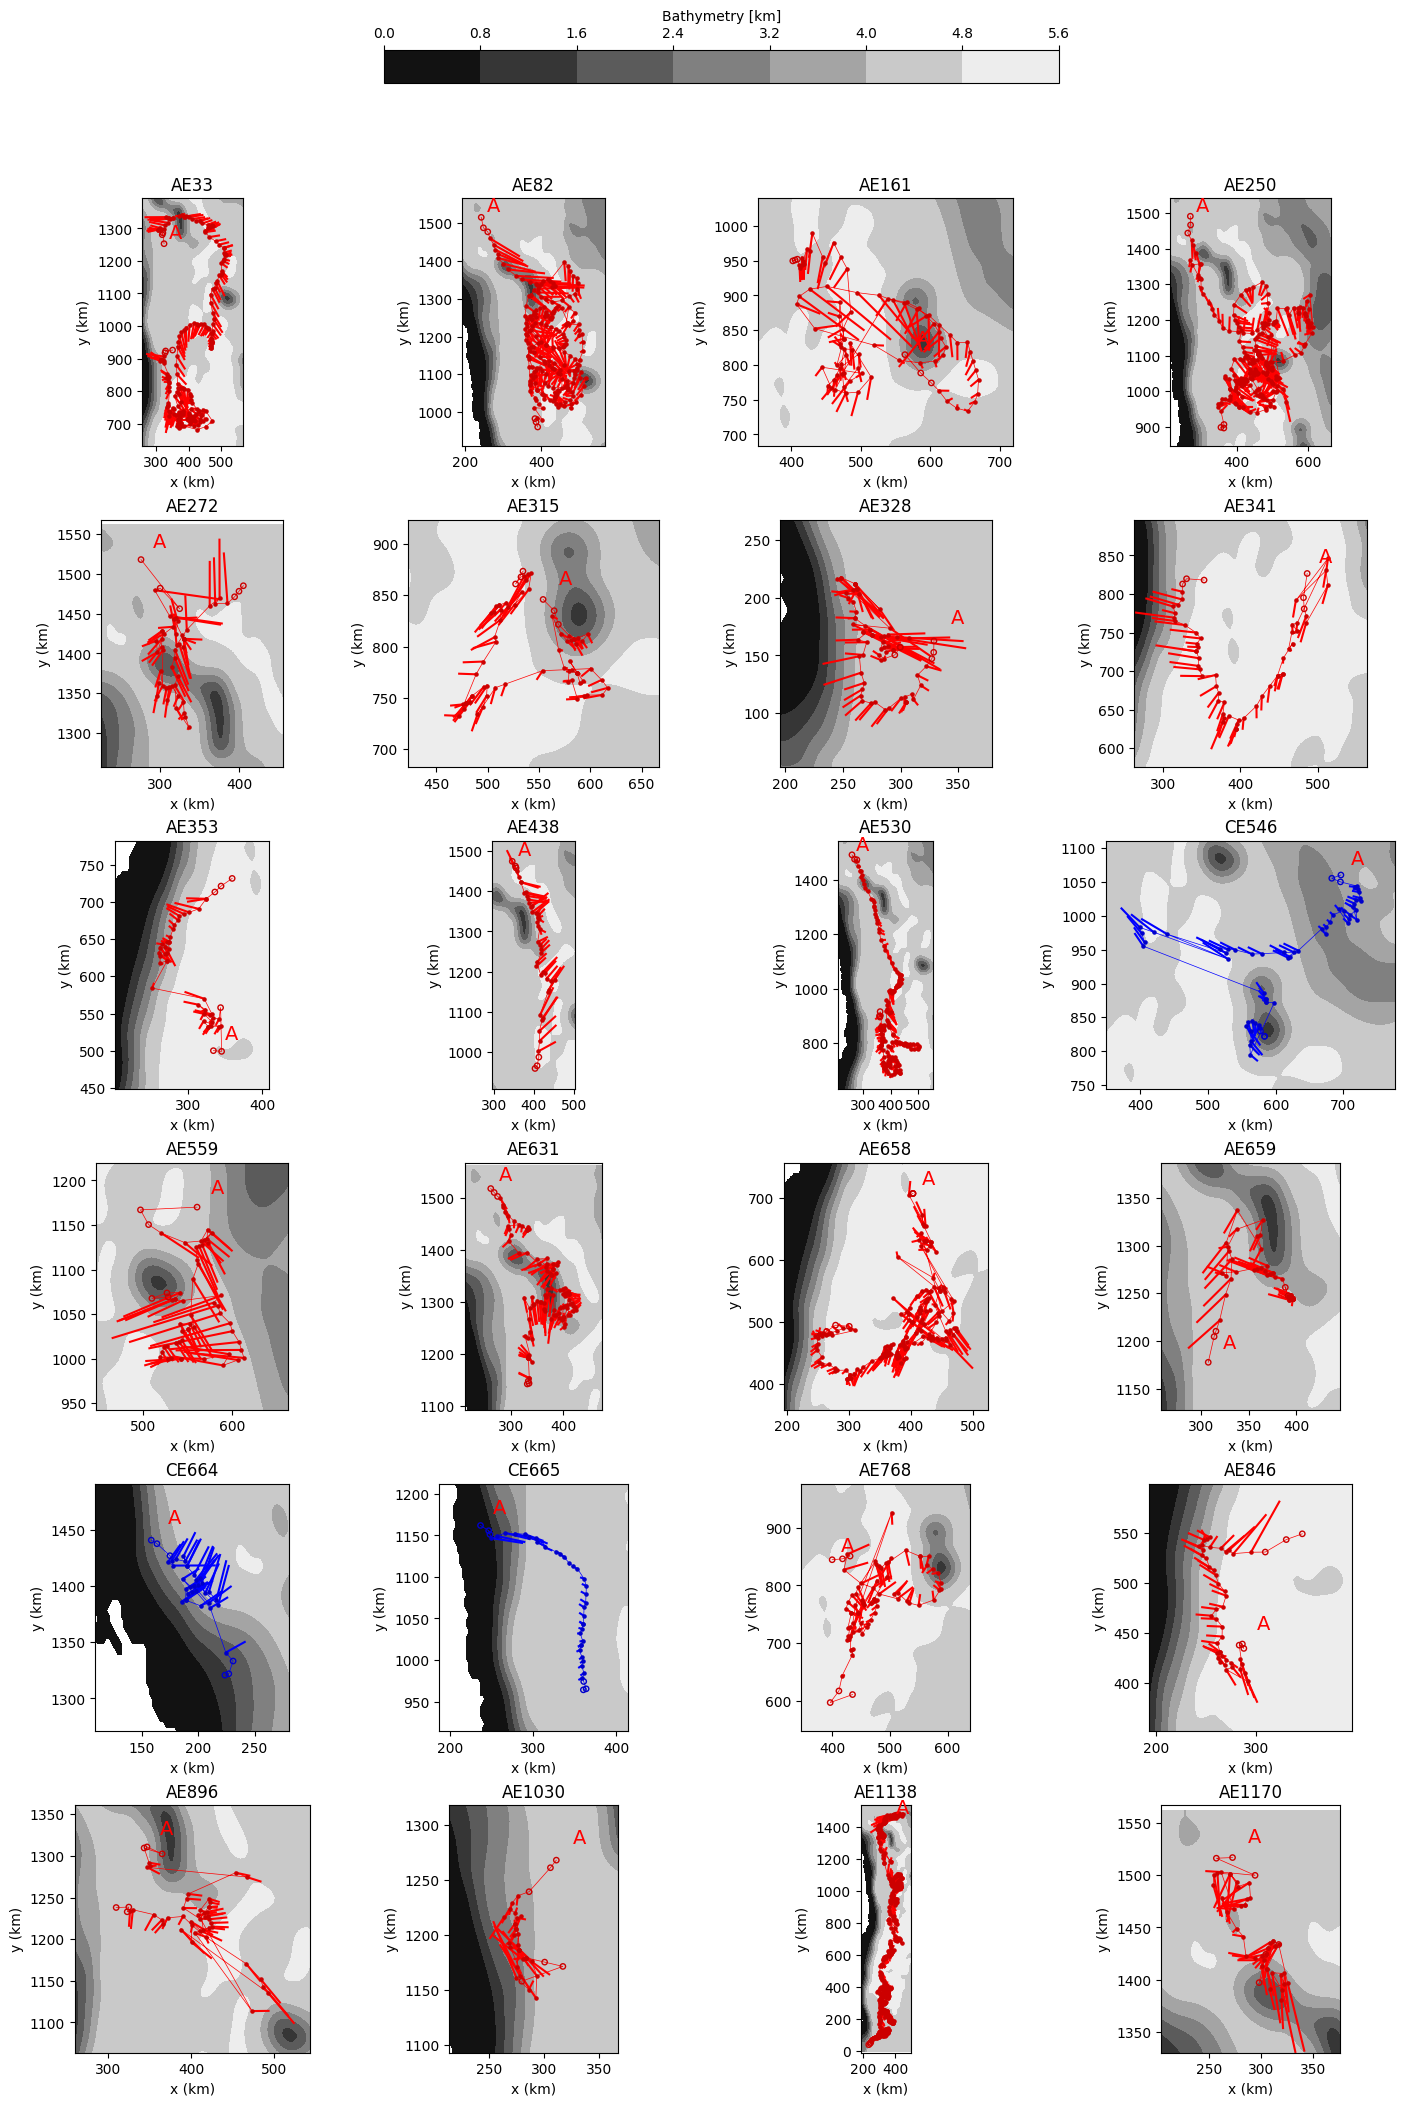

In [17]:
fig, axs = plt.subplots(6, 4, figsize=(14, 21), constrained_layout=True)

axs = axs.ravel()

m = None
for ax, eddy in zip(axs, eddies):
    fig, ax, m = plot_single_eddy_tilt(
        eddy, df_ameda,
        X_grid, Y_grid, h, mask_rho,
        gap=50,
        ax=ax
    )

cbar = fig.colorbar(m, ax=axs, location='top', shrink=0.5)
cbar.set_label('Bathymetry [km]')


Text(0.5, 0, 'Tilt bearing - slope bearing [deg]')

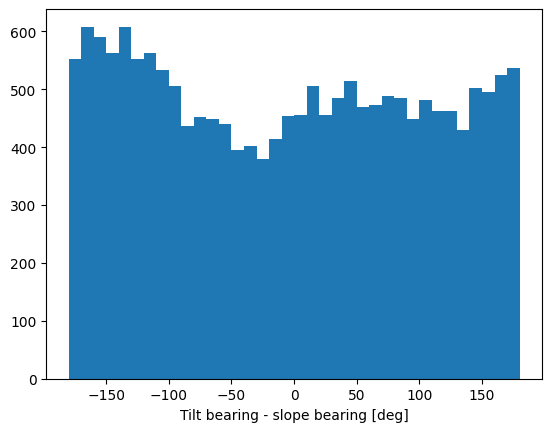

In [18]:
dhdy, dhdx = np.gradient(h, X_grid[:,0], Y_grid[0,:])

gx = dhdx[df_ameda.ic, df_ameda.jc]   # xward component
gy = dhdy[df_ameda.ic, df_ameda.jc]   # yward component

df_ameda['slope_bearing'] = (90 - np.degrees(np.arctan2(gx, gy)) + 20) % 360

df_ameda['theta'] = ((df_ameda.TiltDir - df_ameda.slope_bearing + 180) % 360) - 180

df_eddies_shelf = df_ameda[df_ameda.Eddy.isin(df_eddies_shelf.Eddy.unique())].copy()

plt.hist(df_eddies_shelf.theta, bins=np.arange(-180, 181, 10))
plt.xlabel('Tilt bearing - slope bearing [deg]')


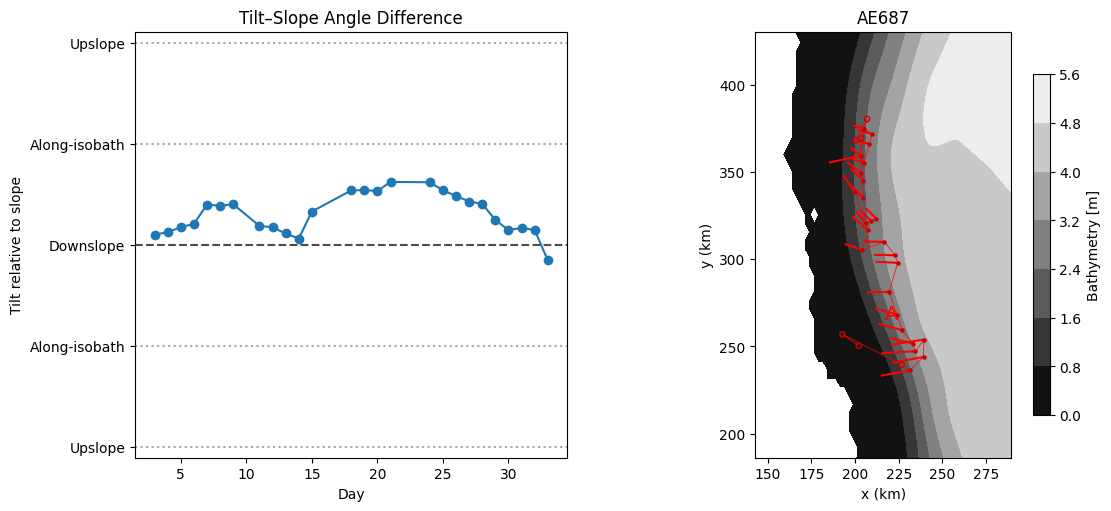

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)

eddy = 687

# Left panel: theta time series
df = df_ameda[df_ameda.Eddy == eddy].copy()

axs[0].plot(df.Day - df.Day.iloc[0], df.theta, '-o')

axs[0].axhline(0, color='k', ls='--', alpha=0.7)
axs[0].axhline(90, color='grey', ls=':', alpha=0.7)
axs[0].axhline(-90, color='grey', ls=':', alpha=0.7)
axs[0].axhline(180, color='grey', ls=':', alpha=0.7)
axs[0].axhline(-180, color='grey', ls=':', alpha=0.7)

axs[0].set_yticks(
    [-180, -90, 0, 90, 180],
    ['Upslope', 'Along-isobath', 'Downslope', 'Along-isobath', 'Upslope']
)

axs[0].set_xlabel('Day')
axs[0].set_ylabel('Tilt relative to slope')
axs[0].set_ylim(-190, 190)
axs[0].set_title('Tilt–Slope Angle Difference')

# Right panel: eddy map
fig, ax_map, m = plot_single_eddy_tilt(
    eddy, df_ameda,
    X_grid, Y_grid, h, mask_rho,
    gap=50,
    ax=axs[1]
)

cbar = fig.colorbar(m, ax=axs[1], shrink=0.8)
cbar.set_label('Bathymetry [m]')


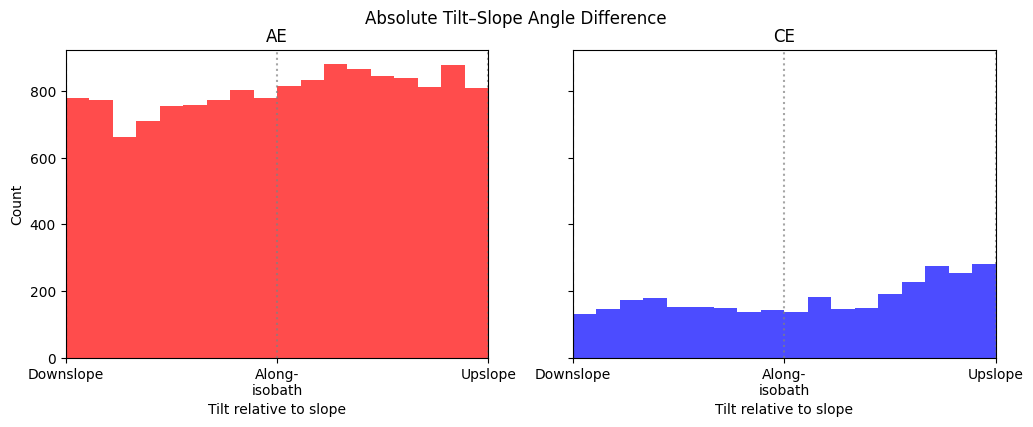

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

bins = np.arange(0, 181, 10)

for ax, cyc, clr in zip(axs, ['AE', 'CE'], ['r', 'b']):

    theta = np.abs(
        df_eddies_shelf.loc[
            df_eddies_shelf.Cyc == cyc,
            'theta'
        ].dropna()
    )

    ax.hist(theta, bins=bins, color=clr, alpha=0.7)

    ax.axvline(0, color='k', ls='--', alpha=0.7)
    ax.axvline(90, color='grey', ls=':', alpha=0.7)
    ax.axvline(180, color='grey', ls=':', alpha=0.7)

    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Downslope',
        'Along-\nisobath',
        'Upslope'
    ])

    ax.set_xlim(0, 180)
    ax.set_title(cyc)

axs[0].set_ylabel('Count')
axs[0].set_xlabel('Tilt relative to slope')
axs[1].set_xlabel('Tilt relative to slope')

fig.suptitle('Absolute Tilt–Slope Angle Difference')
plt.show()
